# Candlestick Pattern Recognition — Henry

WM9B7 AIDL | NQ Futures 15-min | One-vs-Rest TCN | Multi-Bandwidth Labeling | SHAP

**Strategy**: 4 independent binary classifiers, one per pattern type (head_shoulders, inverse_head_shoulders, double_top, double_bottom). Follows TEAM_STANDARDS.md. All config in configs/local/henry.experiment.yaml.

## 0. Setup

In [1]:
import sys, warnings, copy
warnings.filterwarnings("ignore")
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader

from candlestick.config import load_config
from candlestick.data import load_raw_ohlcv, resample_ohlcv
from candlestick.smoothing import smooth_and_extract
from candlestick.labeling import multi_bandwidth_scan, build_label_array
from candlestick.dataset import build_windows, PatternDataset
from candlestick.model import build_model
from candlestick.training import train_model, save_run_artifacts
from candlestick.evaluation import (
    evaluate_model, print_evaluation, plot_learning_curves,
    plot_confusion_matrix, compute_shap_values,
    plot_shap_feature_importance, plot_shap_timeseries,
)

cfg_base = load_config("configs/config.yaml", "configs/local/henry.experiment.yaml")

SEED = cfg_base["project"]["seed"]
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

PATTERNS = ["head_shoulders", "inverse_head_shoulders", "double_top", "double_bottom"]
THRESH_KEY = "decision_threshold"

print(f"Device : {DEVICE}")
print(f"Patterns: {PATTERNS}")


Device : mps
Patterns: ['head_shoulders', 'inverse_head_shoulders', 'double_top', 'double_bottom']


## 1. Data Loading & Resampling

In [2]:
df_1min = load_raw_ohlcv(cfg_base)
df      = resample_ohlcv(df_1min, cfg_base)
ohlcv   = df[["open","high","low","close","volume"]].values.astype(np.float64)
close   = df["close"].values.astype(np.float64)
volume  = df["volume"].values.astype(np.float64)

print(f"1-min bars : {len(df_1min):,}")
print(f"15-min bars: {len(df):,}")
print(f"Date range : {df.index.min().date()} to {df.index.max().date()}")


1-min bars : 1,769,935
15-min bars: 118,006
Date range : 2021-01-03 to 2026-01-02


## 2. NW Smoothing — Visualisation

Single-bandwidth visualisation for inspection. Actual labeling uses multi-bandwidth scan (Section 3).

Bandwidth: 5.0 | Extrema: 10409


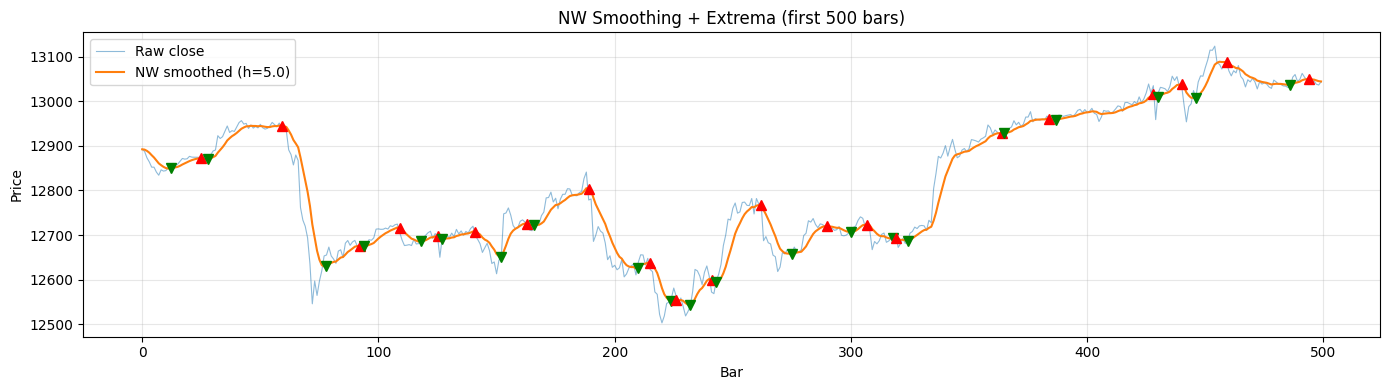

In [3]:
m_hat, extrema_viz, bw = smooth_and_extract(close, cfg_base)
print(f"Bandwidth: {bw:.1f} | Extrema: {len(extrema_viz)}")

fig, ax = plt.subplots(figsize=(14, 4))
ws, we = 0, min(500, len(close))
ax.plot(close[ws:we], label="Raw close", alpha=0.5, lw=0.8)
ax.plot(m_hat[ws:we], label=f"NW smoothed (h={bw:.1f})", lw=1.5)
for e in extrema_viz:
    if ws <= e["bar"] < we:
        c, mk = ("red","^") if e["type"]=="max" else ("green","v")
        ax.plot(e["bar"]-ws, e["value"], marker=mk, color=c, markersize=7, zorder=5)
ax.set_title("NW Smoothing + Extrema (first 500 bars)")
ax.set_xlabel("Bar"); ax.set_ylabel("Price"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Multi-Bandwidth Pattern Scanning

Scanning at a single bandwidth (bw=5) yields only 12 confirmed patterns across 5 years.
We scan at bandwidths [3, 5, 8, 10, 15], each resolving patterns at a different scale,
then deduplicate overlapping detections (same pattern type, anchor bars within 80 bars).

Ref: config key .

In [4]:
print("Confirmed patterns per type (multi-bandwidth scan):")
print(f"{'Pattern':30s} {'Confirmed':>9} {'Unconfirmed':>11}")
print("-" * 54)
scan_cache = {}
for pt in PATTERNS:
    cands = multi_bandwidth_scan(close, volume, cfg_base, pattern_type=pt)
    pos = sum(1 for c in cands if c.label==1)
    neg = sum(1 for c in cands if c.label==0)
    scan_cache[pt] = cands
    print(f"{pt:30s} {pos:>9d} {neg:>11d}")

Confirmed patterns per type (multi-bandwidth scan):
Pattern                        Confirmed Unconfirmed
------------------------------------------------------
head_shoulders                       156         215
inverse_head_shoulders               217         252
double_top                           179         299
double_bottom                        217         248


## 4. One-vs-Rest Training

One binary TCN classifier per pattern type.
Each model is trained independently on windows anchored at that pattern's breakout bars.

Design decisions:
- **Focal loss** (gamma=2.0): down-weights easy negatives, addresses 1:10 class imbalance
- **Inverse-frequency class weights**: computed per-pattern from training split
- **Data augmentation**: 4x jitter + magnitude scale + time warp on positive windows (training only)
- **Time-based split**: 70/15/15 — no data leakage across time
- **Decision threshold**: tuned on validation set to maximise macro-F1


In [5]:
trained = {}   # stores {pattern: {model, result, thresh, X_te, y_te}}

MIN_VAL_POS_FOR_THRESH_TUNING = 5  # fallback to 0.5 if val positives below this

def _anchor_bar(c):
    return c.breakout_bar if c.breakout_bar is not None else c.extrema_indices[-1]

for pt in PATTERNS:
    print()
    print(f"{'='*55}")
    print(f"Pattern: {pt}")
    print("="*55)

    cfg = copy.deepcopy(cfg_base)
    cfg["project"]["run_name"] = f"henry_{pt}_v1"

    # Per-pattern lookback: H&S/IHS use 160 bars, DT/DB use 80 bars
    per_lb = cfg["windowing"].get("per_pattern_lookback", {})
    cfg["windowing"]["lookback_bars"] = per_lb.get(pt, cfg["windowing"]["lookback_bars"])
    print(f"Lookback: {cfg['windowing']['lookback_bars']} bars")

    cands = scan_cache[pt]
    pos   = sum(1 for c in cands if c.label==1)
    if pos < 3:
        print(f"SKIP — only {pos} positive samples")
        continue

    # --- Time-based split on candidates (not on windows) ---
    # Sort by anchor bar so train/val/test are chronologically ordered.
    cands_sorted = sorted(cands, key=_anchor_bar)
    n_c = len(cands_sorted)
    ec  = cfg["evaluation"]
    i_val  = int(n_c * ec["train_ratio"])
    i_test = int(n_c * (ec["train_ratio"] + ec["val_ratio"]))

    cands_tr = cands_sorted[:i_val]
    cands_va = cands_sorted[i_val:i_test]
    cands_te = cands_sorted[i_test:]

    # Bar boundaries keep random negatives inside each split's time range.
    bar_split1 = max(_anchor_bar(c) for c in cands_tr) + 1 if cands_tr else 0
    bar_split2 = max(_anchor_bar(c) for c in cands_va) + 1 if cands_va else bar_split1

    # Embargo: start val/test one full look-back after the previous split ends,
    # so no window in a later split shares any bar with an earlier split.
    EMBARGO = cfg["windowing"]["lookback_bars"]

    labels = build_label_array(len(ohlcv), cands, cfg)

    # Augmentation only on training split — no leakage into val/test.
    X_tr, y_tr = build_windows(ohlcv, labels, cands_tr, cfg,
                                augment=True,  bar_lo=0,          bar_hi=bar_split1)
    X_va, y_va = build_windows(ohlcv, labels, cands_va, cfg,
                                augment=False, bar_lo=bar_split1 + EMBARGO,  bar_hi=bar_split2)
    X_te, y_te = build_windows(ohlcv, labels, cands_te, cfg,
                                augment=False, bar_lo=bar_split2 + EMBARGO)

    n_neg = int((y_tr==0).sum()); n_pos = int((y_tr==1).sum())
    if n_pos == 0:
        print("SKIP — no positives in train split")
        continue
    cw = [1.0, n_neg/n_pos]
    print(f"Candidates: train={len(cands_tr)} val={len(cands_va)} test={len(cands_te)}")
    print(f"Windows:    train pos={y_tr.sum()} neg={(y_tr==0).sum()} | "
          f"val pos={y_va.sum()} neg={(y_va==0).sum()} | "
          f"test pos={y_te.sum()} neg={(y_te==0).sum()}")
    print(f"Class weight pos={cw[1]:.1f}")

    tr_loader = DataLoader(PatternDataset(X_tr, y_tr), batch_size=cfg["training"]["batch_size"], shuffle=True)
    va_loader = DataLoader(PatternDataset(X_va, y_va), batch_size=64)

    model  = build_model(cfg)
    result = train_model(model, tr_loader, va_loader, cfg, class_weights=cw)
    save_run_artifacts(result, cfg)

    # Threshold tuning on val set.
    # If val positives < MIN_VAL_POS_FOR_THRESH_TUNING, val F1 is too noisy
    # to tune on — fall back to the neutral default of 0.5.
    model.eval(); dev = next(model.parameters()).device
    def _probs(Xd, yd):
        ps, ts = [], []
        with torch.no_grad():
            for Xb, yb in DataLoader(PatternDataset(Xd, yd), batch_size=64):
                ps.append(torch.softmax(model(Xb.to(dev)),dim=1)[:,1].cpu().numpy())
                ts.append(yb.numpy())
        return np.concatenate(ps), np.concatenate(ts)

    vp, vt = _probs(X_va, y_va)
    tp, tt = _probs(X_te, y_te)

    val_pos_count = int((vt == 1).sum())
    if val_pos_count < MIN_VAL_POS_FOR_THRESH_TUNING:
        best_t = 0.5
        print(f"Val positives={val_pos_count} < {MIN_VAL_POS_FOR_THRESH_TUNING} — using default threshold 0.5")
    else:
        best_t = max(np.arange(0.05,0.98,0.01),
                     key=lambda t: f1_score(vt,(vp>=t).astype(int),zero_division=0))
        print(f"Best threshold (val): {best_t:.2f}")

    trained[pt] = dict(model=model, result=result, thresh=best_t,
                       X_tr=X_tr, X_va=X_va, X_te=X_te,
                       y_tr=y_tr, y_va=y_va, y_te=y_te,
                       te_probs=tp, te_true=tt)


Pattern: head_shoulders
Lookback: 160 bars
Candidates: train=259 val=56 test=56
Windows:    train pos=336 neg=1120 | val pos=25 neg=250 | test pos=19 neg=190
Class weight pos=3.3
Epoch   1/60 | Train loss 0.6679 | Val loss 0.1719 | Val F1(macro) 0.7806 | Val F1(pos) 0.6250
Epoch   5/60 | Train loss 0.2421 | Val loss 0.1009 | Val F1(macro) 0.8585 | Val F1(pos) 0.7500
Epoch  10/60 | Train loss 0.1738 | Val loss 0.0917 | Val F1(macro) 0.8728 | Val F1(pos) 0.7742
Epoch  15/60 | Train loss 0.1272 | Val loss 0.0756 | Val F1(macro) 0.8802 | Val F1(pos) 0.7869
Epoch  20/60 | Train loss 0.1141 | Val loss 0.0793 | Val F1(macro) 0.8878 | Val F1(pos) 0.8000
Epoch  25/60 | Train loss 0.0787 | Val loss 0.0732 | Val F1(macro) 0.8585 | Val F1(pos) 0.7500
Epoch  30/60 | Train loss 0.0807 | Val loss 0.0805 | Val F1(macro) 0.8690 | Val F1(pos) 0.7667
Early stopping at epoch 33 (best=23)
Artifacts saved to outputs/henry_head_shoulders_v1
Best threshold (val): 0.72

Pattern: inverse_head_shoulders
Lookbac

## 5. Test Set Evaluation

In [6]:
from candlestick.evaluation import threshold_metrics

# Headline metric = positive-class F1 and PR-AUC.
# Macro F1 is kept for reference only: with ~1:10 imbalance it averages in the
# easy negative class and overstates performance.
summary = []
for pt, d in trained.items():
    m = threshold_metrics(d["te_true"], d["te_probs"], d["thresh"])
    summary.append({"pattern": pt,
                    "test_pos": int((d["te_true"] == 1).sum()),
                    "threshold": round(d["thresh"], 2),
                    "f1_pos": round(m["f1"], 4), "precision": round(m["precision"], 4),
                    "recall": round(m["recall"], 4), "pr_auc": round(m["pr_auc"], 4),
                    "f1_macro": round(m["f1_macro"], 4)})

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print(f"\nMean F1(pos): {summary_df.f1_pos.mean():.4f} | Mean PR-AUC: {summary_df.pr_auc.mean():.4f} "
      f"| (Mean F1 macro, reference only: {summary_df.f1_macro.mean():.4f})")


               pattern  test_pos  threshold  f1_pos  precision  recall  pr_auc  f1_macro
        head_shoulders        19       0.72  0.8000     0.7619  0.8421  0.8390    0.8894
inverse_head_shoulders        33       0.76  0.6667     0.8571  0.5455  0.7571    0.8199
            double_top        19       0.67  0.5405     0.5556  0.5263  0.6918    0.7480
         double_bottom        36       0.60  0.5843     0.4906  0.7222  0.6681    0.7658

Mean F1(pos): 0.6479 | Mean PR-AUC: 0.7390 | (Mean F1 macro, reference only: 0.8058)


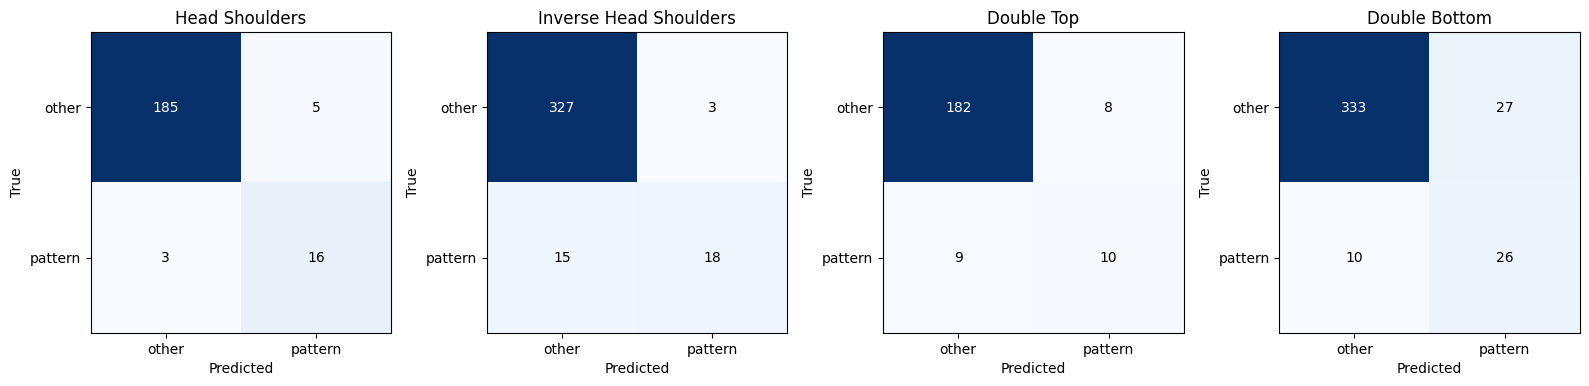

In [7]:
fig, axes = plt.subplots(1, len(trained), figsize=(4*len(trained), 4))
if len(trained) == 1: axes = [axes]
for ax, (pt, d) in zip(axes, trained.items()):
    preds = (d["te_probs"] >= d["thresh"]).astype(int)
    cm = confusion_matrix(d["te_true"], preds)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["other","pattern"]); ax.set_yticklabels(["other","pattern"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(pt.replace("_"," ").title())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                    color="white" if cm[i,j]>cm.max()/2 else "black")
plt.tight_layout(); plt.show()



--- head_shoulders ---


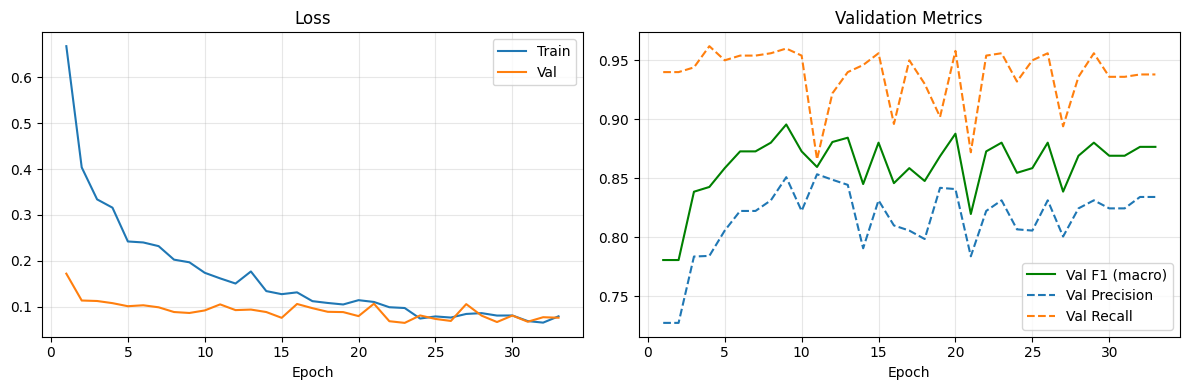


--- inverse_head_shoulders ---


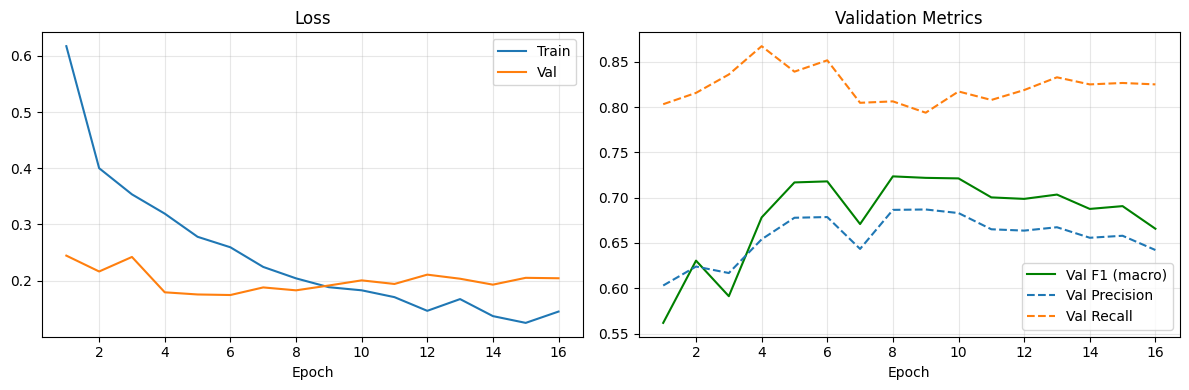


--- double_top ---


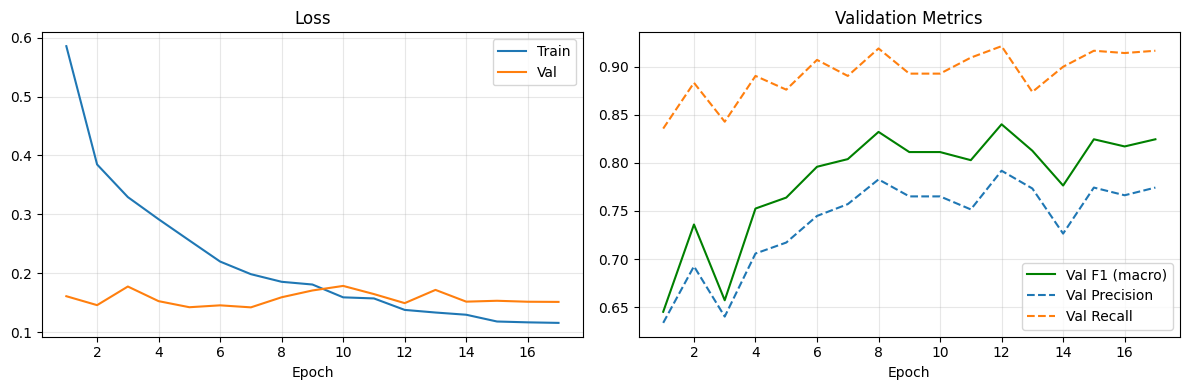


--- double_bottom ---


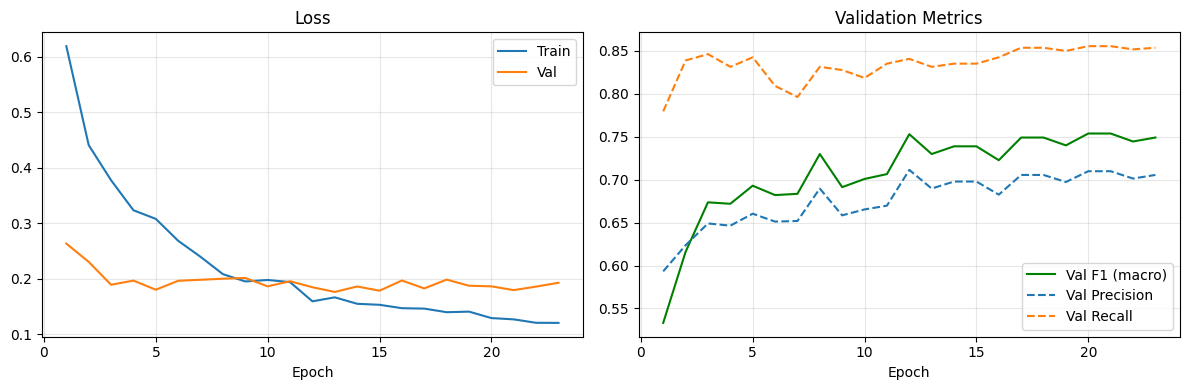

In [8]:
for pt, d in trained.items():
    print()
    print(f"--- {pt} ---")
    plot_learning_curves(d["result"]["history"])


## 6. SHAP Explainability

GradientExplainer attributes each (time step, feature) pair in the 80-bar window.
Run on CPU — GradientExplainer is unstable on MPS.


--- SHAP: head_shoulders ---
Saved: outputs/henry_head_shoulders_v1/shap_feature_importance.png


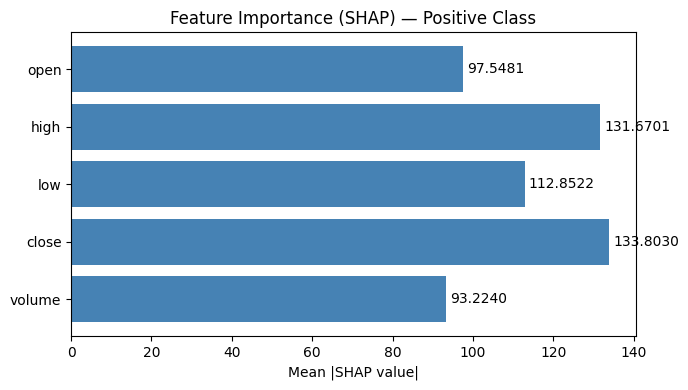

Saved: outputs/henry_head_shoulders_v1/shap_close_timeseries.png


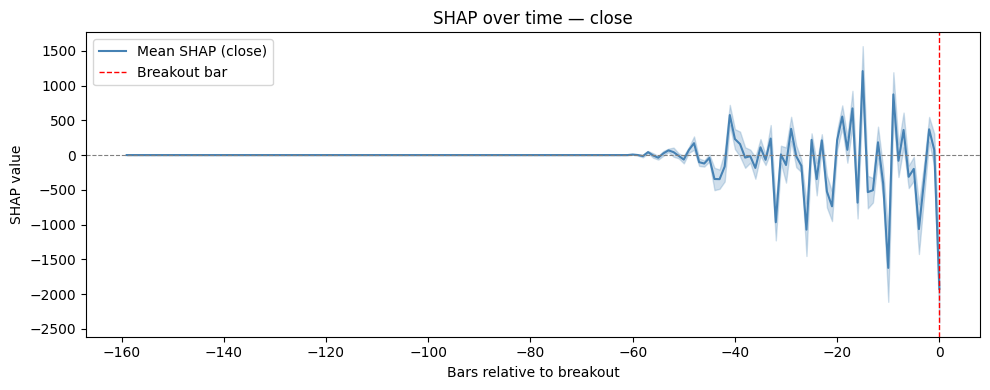


--- SHAP: inverse_head_shoulders ---
Saved: outputs/henry_inverse_head_shoulders_v1/shap_feature_importance.png


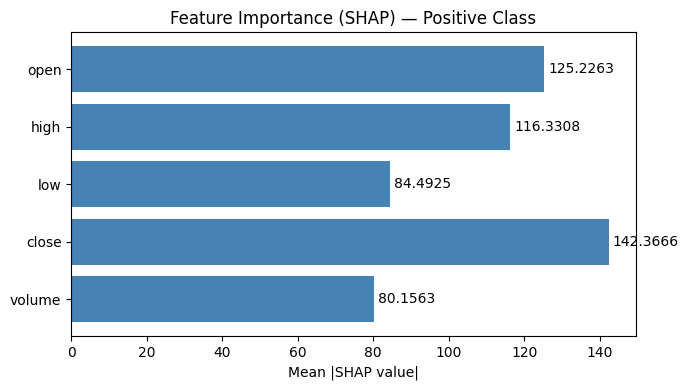

Saved: outputs/henry_inverse_head_shoulders_v1/shap_close_timeseries.png


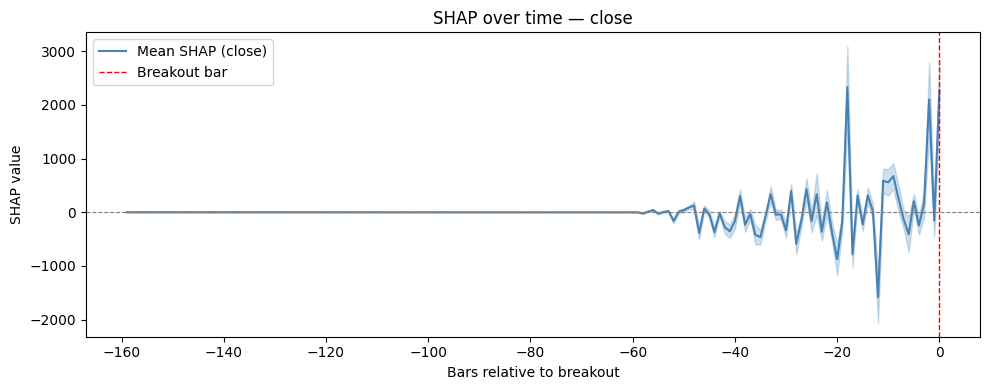


--- SHAP: double_top ---
Saved: outputs/henry_double_top_v1/shap_feature_importance.png


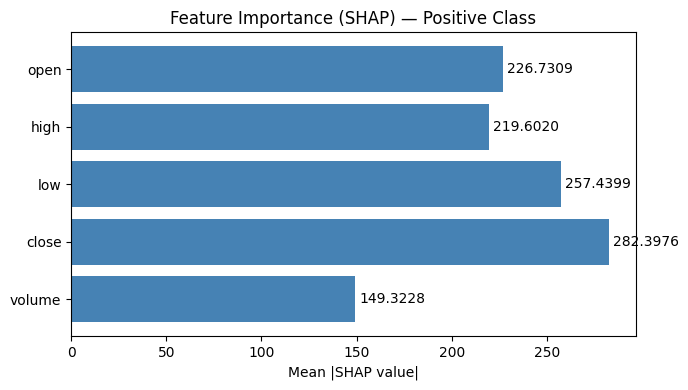

Saved: outputs/henry_double_top_v1/shap_close_timeseries.png


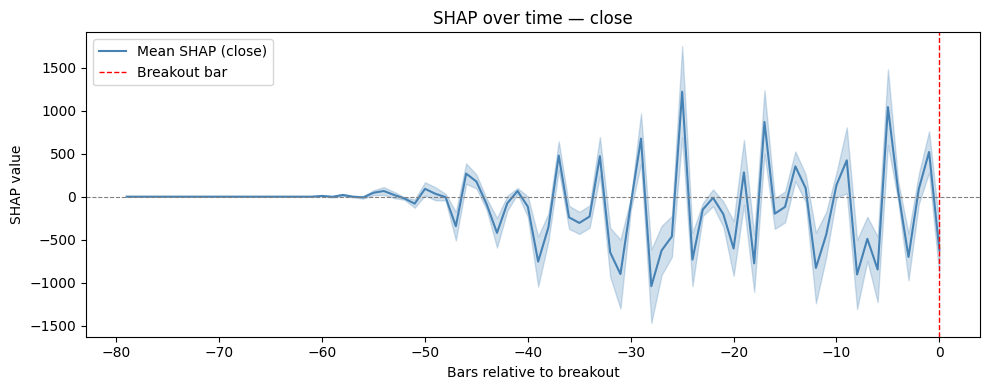


--- SHAP: double_bottom ---
Saved: outputs/henry_double_bottom_v1/shap_feature_importance.png


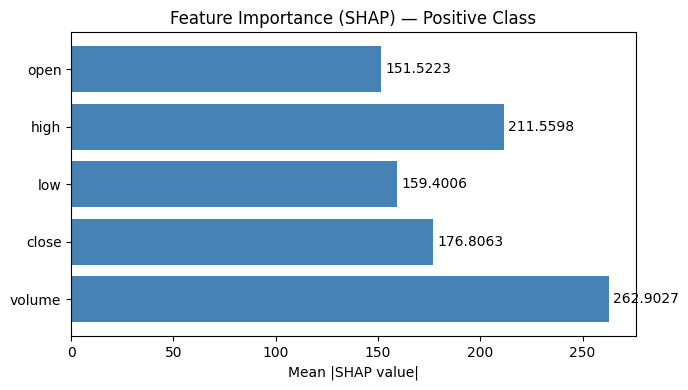

Saved: outputs/henry_double_bottom_v1/shap_close_timeseries.png


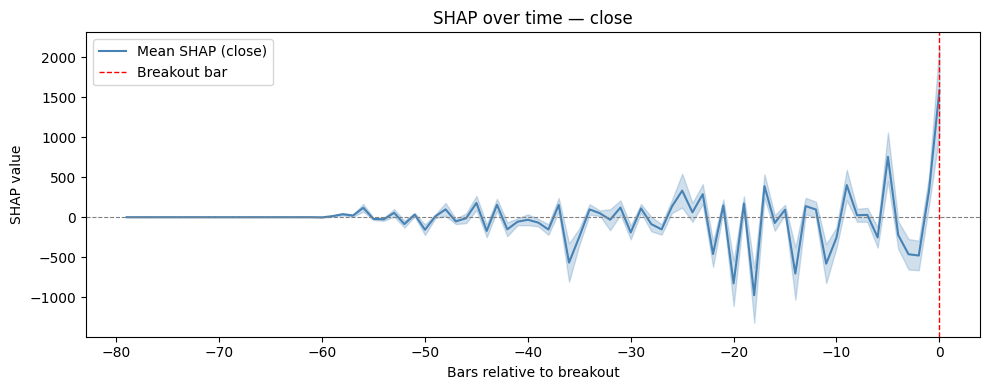

In [9]:
for pt, d in trained.items():
    print()
    print(f"--- SHAP: {pt} ---")
    X_te_pos = d["X_te"][d["y_te"]==1]
    if len(X_te_pos) == 0:
        print("No test positives — skipping")
        continue

    model_cpu = build_model(cfg_base)
    model_cpu.load_state_dict({k: v.cpu() for k, v in d["model"].state_dict().items()})
    model_cpu.cpu().eval()

    shap_vals = compute_shap_values(model_cpu, d["X_tr"], X_te_pos,
                                     n_background=100, device=torch.device("cpu"))
    out_dir = Path(cfg_base["paths"]["outputs_root"]) / f"henry_{pt}_v1"
    plot_shap_feature_importance(shap_vals, save_path=out_dir/"shap_feature_importance.png")
    plot_shap_timeseries(shap_vals, feature_idx=3, save_path=out_dir/"shap_close_timeseries.png")


## 7. Summary & Limitations

Results: see the evaluation table printed in Section 5 (positive-class F1, precision, recall, PR-AUC on the held-out, embargoed test split). 
Re-run the notebook to regenerate; do not hand-copy numbers here.

Limitations: few confirmed patterns per type (tens in test), so per-pattern metrics have wide uncertainty; labels come from rule-based detection, so the model learns to reproduce the rules rather than ground truth.


In [10]:
from candlestick.labeling import filter_nested_candidates

# ── Step 1: Diagnostic — how many nested pairs exist per pattern? ──────────
print("Nested candidate diagnostic (Version A scan_cache):")
print(f"{'Pattern':30s} {'Before':>7} {'After':>7} {'Removed':>8}")
print("-" * 56)
scan_cache_filtered = {}
for pt in PATTERNS:
    before = scan_cache[pt]
    after  = filter_nested_candidates(before)
    scan_cache_filtered[pt] = after
    removed = len(before) - len(after)
    pos_b   = sum(1 for c in before if c.label == 1)
    pos_a   = sum(1 for c in after  if c.label == 1)
    print(f"{pt:30s} {len(before):>7d} {len(after):>7d} {removed:>8d}  "
          f"(confirmed: {pos_b} → {pos_a})")

# ── Step 2: Retrain with filter_nested=True ────────────────────────────────
print()
print("Training Version B (filter_nested=True) ...")
trained_filtered = {}

for pt in PATTERNS:
    print()
    print(f"{'='*55}")
    print(f"Pattern: {pt}  [filter_nested]")
    print("="*55)

    cfg = copy.deepcopy(cfg_base)
    cfg["project"]["run_name"] = f"henry_{pt}_v1_filtered"
    per_lb = cfg["windowing"].get("per_pattern_lookback", {})
    cfg["windowing"]["lookback_bars"] = per_lb.get(pt, cfg["windowing"]["lookback_bars"])
    print(f"Lookback: {cfg['windowing']['lookback_bars']} bars")

    cands = scan_cache_filtered[pt]
    pos   = sum(1 for c in cands if c.label == 1)
    if pos < 3:
        print(f"SKIP — only {pos} positive samples after filtering")
        continue

    cands_sorted = sorted(cands, key=_anchor_bar)
    n_c    = len(cands_sorted)
    ec     = cfg["evaluation"]
    i_val  = int(n_c * ec["train_ratio"])
    i_test = int(n_c * (ec["train_ratio"] + ec["val_ratio"]))

    cands_tr = cands_sorted[:i_val]
    cands_va = cands_sorted[i_val:i_test]
    cands_te = cands_sorted[i_test:]

    bar_split1 = max(_anchor_bar(c) for c in cands_tr) + 1 if cands_tr else 0
    bar_split2 = max(_anchor_bar(c) for c in cands_va) + 1 if cands_va else bar_split1

    # Embargo: start val/test one full look-back after the previous split ends,
    # so no window in a later split shares any bar with an earlier split.
    EMBARGO = cfg["windowing"]["lookback_bars"]

    labels = build_label_array(len(ohlcv), cands, cfg)

    X_tr, y_tr = build_windows(ohlcv, labels, cands_tr, cfg,
                                augment=True,  bar_lo=0,         bar_hi=bar_split1)
    X_va, y_va = build_windows(ohlcv, labels, cands_va, cfg,
                                augment=False, bar_lo=bar_split1 + EMBARGO, bar_hi=bar_split2)
    X_te, y_te = build_windows(ohlcv, labels, cands_te, cfg,
                                augment=False, bar_lo=bar_split2 + EMBARGO)

    n_neg = int((y_tr == 0).sum()); n_pos = int((y_tr == 1).sum())
    if n_pos == 0:
        print("SKIP — no positives in train split after filtering")
        continue
    cw = [1.0, n_neg / n_pos]
    print(f"Candidates: train={len(cands_tr)} val={len(cands_va)} test={len(cands_te)}")
    print(f"Windows:    train pos={y_tr.sum()} neg={(y_tr==0).sum()} | "
          f"val pos={y_va.sum()} neg={(y_va==0).sum()} | "
          f"test pos={y_te.sum()} neg={(y_te==0).sum()}")
    print(f"Class weight pos={cw[1]:.1f}")

    tr_loader = DataLoader(PatternDataset(X_tr, y_tr), batch_size=cfg["training"]["batch_size"], shuffle=True)
    va_loader = DataLoader(PatternDataset(X_va, y_va), batch_size=64)

    model  = build_model(cfg)
    result = train_model(model, tr_loader, va_loader, cfg, class_weights=cw)

    model.eval(); dev = next(model.parameters()).device
    def _probs_f(Xd, yd):
        ps, ts = [], []
        with torch.no_grad():
            for Xb, yb in DataLoader(PatternDataset(Xd, yd), batch_size=64):
                ps.append(torch.softmax(model(Xb.to(dev)), dim=1)[:, 1].cpu().numpy())
                ts.append(yb.numpy())
        return np.concatenate(ps), np.concatenate(ts)

    vp, vt = _probs_f(X_va, y_va)
    tp, tt = _probs_f(X_te, y_te)

    val_pos_count = int((vt == 1).sum())
    if val_pos_count < MIN_VAL_POS_FOR_THRESH_TUNING:
        best_t = 0.5
        print(f"Val positives={val_pos_count} < {MIN_VAL_POS_FOR_THRESH_TUNING} — using default threshold 0.5")
    else:
        best_t = max(np.arange(0.05, 0.98, 0.01),
                     key=lambda t: f1_score(vt, (vp >= t).astype(int), zero_division=0))
        print(f"Best threshold (val): {best_t:.2f}")

    trained_filtered[pt] = dict(thresh=best_t, te_probs=tp, te_true=tt)

# ── Step 3: Side-by-side comparison ───────────────────────────────────────
print()
print("=" * 80)
print("ABLATION RESULT: filter_nested=False (A) vs filter_nested=True (B)")
print("=" * 80)
print(f"{'Pattern':30s} {'F1_A':>6} {'F1_B':>6} {'Δ F1':>7}  {'Prec_A':>7} {'Prec_B':>7}  {'Rec_A':>6} {'Rec_B':>6}")
print("-" * 80)

for pt in PATTERNS:
    if pt not in trained or pt not in trained_filtered:
        print(f"{pt:30s}  (skipped)")
        continue
    dA = trained[pt]
    dB = trained_filtered[pt]

    predsA = (dA["te_probs"] >= dA["thresh"]).astype(int)
    predsB = (dB["te_probs"] >= dB["thresh"]).astype(int)

    f1A  = f1_score(dA["te_true"], predsA, zero_division=0)
    f1B  = f1_score(dB["te_true"], predsB, zero_division=0)
    preA = precision_score(dA["te_true"], predsA, zero_division=0)
    preB = precision_score(dB["te_true"], predsB, zero_division=0)
    recA = recall_score(dA["te_true"], predsA, zero_division=0)
    recB = recall_score(dB["te_true"], predsB, zero_division=0)

    delta = f1B - f1A
    marker = " ▲" if delta > 0.01 else (" ▼" if delta < -0.01 else "  ")
    print(f"{pt:30s} {f1A:>6.4f} {f1B:>6.4f} {delta:>+7.4f}{marker} "
          f"{preA:>7.4f} {preB:>7.4f}  {recA:>6.4f} {recB:>6.4f}")

Nested candidate diagnostic (Version A scan_cache):
Pattern                         Before   After  Removed
--------------------------------------------------------
head_shoulders                     371     259      112  (confirmed: 156 → 141)
inverse_head_shoulders             469     316      153  (confirmed: 217 → 185)
double_top                         478     471        7  (confirmed: 179 → 179)
double_bottom                      465     459        6  (confirmed: 217 → 215)

Training Version B (filter_nested=True) ...

Pattern: head_shoulders  [filter_nested]
Lookback: 160 bars
Candidates: train=181 val=39 test=39
Windows:    train pos=303 neg=1010 | val pos=22 neg=220 | test pos=17 neg=170
Class weight pos=3.3
Epoch   1/60 | Train loss 0.5337 | Val loss 0.1995 | Val F1(macro) 0.5853 | Val F1(pos) 0.3729
Epoch   5/60 | Train loss 0.2064 | Val loss 0.0575 | Val F1(macro) 0.8749 | Val F1(pos) 0.7778
Epoch  10/60 | Train loss 0.1505 | Val loss 0.0663 | Val F1(macro) 0.8923 | Val F1(

## 8. Ablation — Nested Pattern Filter

Controlled experiment: does removing candidates whose bar span is fully contained
within a larger same-type candidate reduce overfitting and improve test F1?

- **Version A** (baseline): `filter_nested=false` — results already in Section 5.
- **Version B** (filtered): `filter_nested=true` — retrain all 4 models, compare.

Hypothesis: if nested patterns inflate the training set with redundant windows that
share price data with the outer pattern, removing them should improve generalisation
(higher test F1 with similar or lower train F1).